# MP3: Machine Learning Project

dataset used: https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction/data

### Summary of results:

**Q1**

Most numerical features, like `duration` and `days_left`, showed somewhat spread-out distributions and were not perfectly normal. The `price` column was right-skewed with some high value outliers. Categorical features like airline and city columns were unevenly distributed, with some categories appearing much more frequently than others.

---

**Q2**

Missing values were handled using `dropna()`. This method was chosen because the dataset contained little to no missing values, so removing those rows did not significantly impact the size or quality of the dataset. This approach also avoids introducing bias that could result from imputation methods (like filling with mean or median values)

---

**Q3**

Categorical variables were encoded using one-hot encoding (`pd.get_dummies`). This method was chosen because it prevents the model from assuming any ordinal relationship between categories, which would occur if label encoding were used. One-hot encoding makes sure that each category is treated independently

---

**Q4**

Outliers in the `price` column were removed using the IQR method. Values outside the range `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]` were excluded. This method was chosen because it is robust to skewed distributions and removes extreme values without being overly sensitive to them. Outliers in price could represent rare luxury flights or data anomalies that would disproportionately influence model training, especially for regression models minimizing squared error

---

**Q5**

The data was standardized using StandardScaler, which transforms features to have a mean of 0 and a standard deviation of 1. StandardScaler was applied primarily for models like KNN and Linear Regression. Tree-based models are not sensitive to scaling, but scaling was applied uniformly for consistency

---

**Q6**

This problem was treated as a regression task because the target variable (price) is continuous. Four regression models were trained and evaluated:

- **Linear Regression:** Achieved an R^2 score of ~0.927 on both training and testing data. Performance was consistent but lower than other models.
- **Decision Tree:** After adjusting hyperparameters, the model achieved R^2 ≈ 0.965 on training and R^2 ≈ 0.963 on testing. The consistant performance indicates good generalization.
- **Random Forest:** Achieved the best overall performance, with training R^2 ≈ 0.981 and testing R^2 ≈ 0.978, along with the lowest RMSE, though KNN achieved a slightly lower MAE.
- **KNN:** Performed well with training R^2 ≈ 0.984 and testing R^2 ≈ 0.975, but showed slightly more variance than other models.

Random Forest performed the best overall, having the highest accuracy on the test set while maintaining a good balance between training and testing performance. This suggests it generalizes better than the other models.

---

**Q7**

None of the models showed severe signs of bias or variance.

Linear Regression showed slight bias because its performance was lower than the other models, but it was consistent between training and testing. Decision Tree demonstrated strong generalization, with nearly identical training and testing performance, indicating a good balance between bias and variance after reducing model complexity. 

Random Forest also showed excellent generalization, with high performance and only a small difference between training and testing scores. KNN exhibited a small amount of variance, as its training performance was slightly higher than its testing performance.

Overall, all models generalized well to unseen data, and each explained a large portion of the variance in the target variable, with no model showing extreme underfitting or overfitting.

### Code to clean data

load libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Clean_Dataset.csv")
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [2]:
# df.info()
# df.describe()
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [3]:
# drop useless column
df.drop(["Unnamed: 0"], axis=1, inplace=True)

# and NA values (if any (there aren't))
df.isnull().sum()
df = df.dropna()

one-hot encoding used to avoid introducing ordinal relationships

In [4]:
df = pd.get_dummies(df, drop_first=True)

handle outliers: IQR used because it is robust for skewed distributions

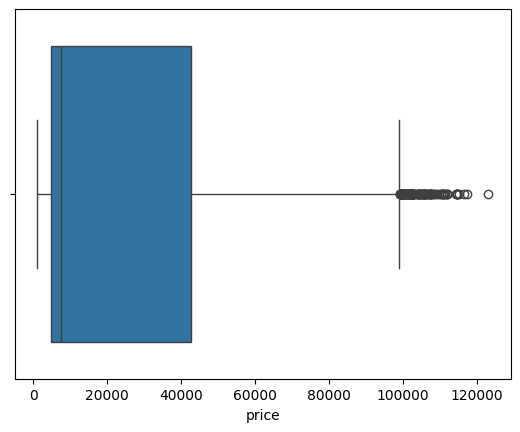

In [5]:
sns.boxplot(x=df["price"])
plt.show()

In [6]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["price"] >= Q1 - 1.5*IQR) & (df["price"] <= Q3 + 1.5*IQR)]

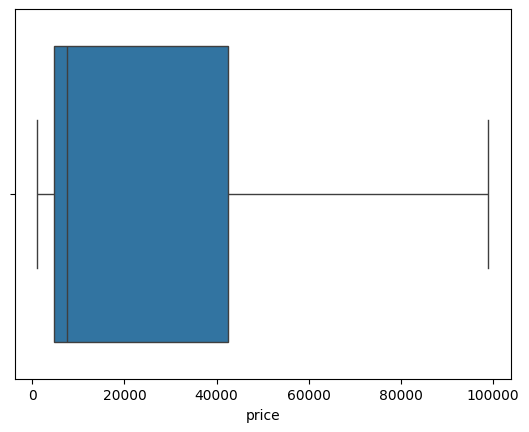

In [7]:
sns.boxplot(x=df["price"])
plt.show()

### Code to train/evaluate models

normalize data, train/test split

In [9]:
X = df.drop("price", axis=1)
y = df["price"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)  # fit ONLY on training
X_test = scaler.transform(X_test)        # transform test

train four models

linear regression

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


decision tree

In [12]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

random forest

<small>this took an hour to run before I limited it....</small>

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

KNN

In [15]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


evaluate them

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(model):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("TRAIN:")
    print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
    print("MAE:", mean_absolute_error(y_train, y_train_pred))
    print("R2:", r2_score(y_train, y_train_pred))

    print("\nTEST:")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print("MAE:", mean_absolute_error(y_test, y_test_pred))
    print("R2:", r2_score(y_test, y_test_pred))
    print("\n---\n")

<small>this took 24ish minutes to run</small>

In [21]:
import warnings
warnings.filterwarnings("ignore")

evaluate(lr)
evaluate(dt)
evaluate(rf)
evaluate(knn)

TRAIN:
RMSE: 6111.761514685238
MAE: 4234.3441145671995
R2: 0.927198307527815

TEST:
RMSE: 6115.113253275489
MAE: 4232.843902597175
R2: 0.9267060716452546

---

TRAIN:
RMSE: 4266.748823895844
MAE: 2396.5643909506466
R2: 0.9645184297175576

TEST:
RMSE: 4318.257690875284
MAE: 2413.6527815377494
R2: 0.9634509493887998

---

TRAIN:
RMSE: 3133.4651251367227
MAE: 1660.7831629810053
R2: 0.9808636807425465

TEST:
RMSE: 3316.2218952917574
MAE: 1745.0797368223432
R2: 0.9784450929330495

---

TRAIN:
RMSE: 2862.93207743527
MAE: 1126.3816510015663
R2: 0.9840253715384143

TEST:
RMSE: 3539.970096379489
MAE: 1432.5285738092857
R2: 0.9754383139026402

---



### Evaluation Results:

---

LINEAR REGRESSION

TRAIN:\
RMSE: 6111.761514685238\
MAE: 4234.3441145671995\
R2: 0.927198307527815

TEST:\
RMSE: 6115.113253275489\
MAE: 4232.843902597175\
R2: 0.9267060716452546

---

DECISION TREE

TRAIN:\
RMSE: 4266.748823895844\
MAE: 2396.5643909506466\
R2: 0.9645184297175576

TEST:\
RMSE: 4318.257690875284\
MAE: 2413.6527815377494\
R2: 0.9634509493887998

---

RANDOM FOREST

TRAIN:\
RMSE: 3133.4651251367227\
MAE: 1660.7831629810053\
R2: 0.9808636807425465

TEST:\
RMSE: 3316.2218952917574\
MAE: 1745.0797368223432\
R2: 0.9784450929330495

---

KNN

TRAIN:\
RMSE: 2862.93207743527\
MAE: 1126.3816510015663\
R2: 0.9840253715384143

TEST:\
RMSE: 3539.970096379489\
MAE: 1432.5285738092857\
R2: 0.9754383139026402